# Intro

Ophélie

# Imports

Cette section vous permet d'importer toutes les librairies utilisées dans ce Jupyter Notebook. Avant de commencer, il est préférable de créer un environnement virtuel, puis installer les librairies mentionnées dans le fichier "requirements.txt".

Commandes à exécuter (à la racine du projet) :
1. python -m venv .venv
2. .venv\Scripts\activate
3. pip install -r requirements.txt

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8') # pretty matplotlib plots

import seaborn as sns
import scipy.stats as stats
from statsmodels.graphics.gofplots import qqplot
import statsmodels.api as sm

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

import optuna
from optuna.visualization import plot_slice


# Données

Description des données

Analysez les données en votre possession

Emettez des hypothèses sur les données qui possèdent le plus d’information selon vous. 

Ophélie

## Récupération et normalisation

Création de deux "tableaux" Panda pour les données d'entrainement et de validation.
Logiquement on va appliquer le même traitement sur les deux jeux de données.

Ensuite, nous allons afficher un résumé de nos données d'entrainement afin d'avoir un visuel de la moyenne, le max, le quartiles, ...

In [2]:
train_raw = pd.read_csv('Data/train.csv', index_col = 'Id')
validation_raw = pd.read_csv('Data/test.csv', index_col = 'Id')

# descriptive statistics summary
train_raw['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Est-ce que notre distribution est normalement distribué ?
Nous allons effectuer un Shapiro-Wilk Test afin de le savoir.

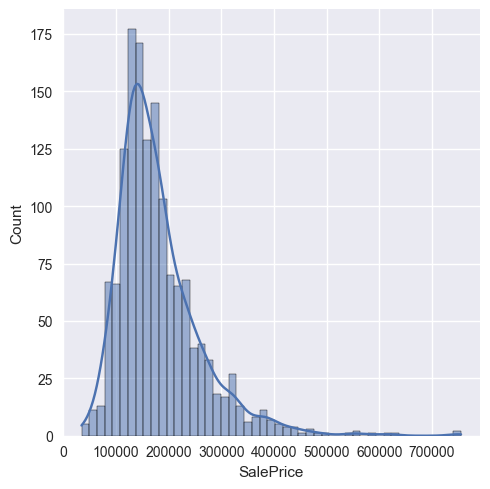

In [3]:
# distribution plot with normal fit
ax = sns.displot(data = train_raw['SalePrice'], kde=True)
plt.show()

The assocated p-value is : 3.2061412312021656e-33
With a threshold α = 0.05, we reject the null hypothesis


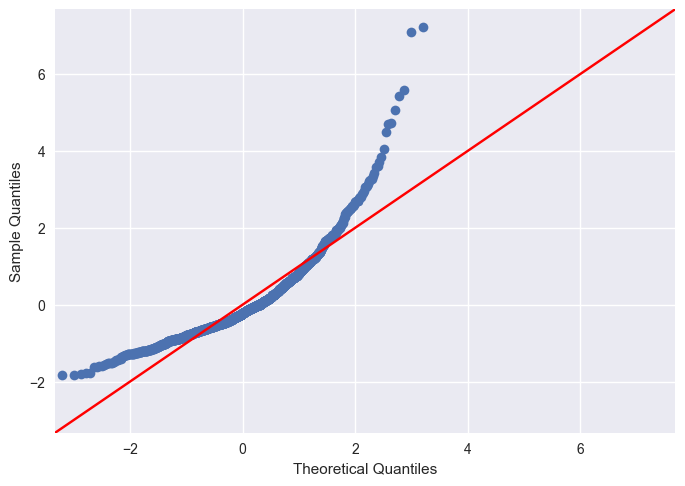

In [4]:
# Shapiro-Wilk Test for normality together with the Q-Q plot
alpha = 0.05
W, p = stats.shapiro(train_raw['SalePrice'])

print('The assocated p-value is : ' + str(p))

if p < alpha : 
    print('With a threshold α = ' + str(alpha) + ', we reject the null hypothesis')
else : 
    print('With a threshold α = ' + str(alpha) + ', we fail to reject the null hypothesis')
    
qqplot(train_raw['SalePrice'], dist = stats.distributions.norm, fit = True, line = '45')
plt.show()

La distribution n'est pas linéaire car il y a des valeurs extrême qui faussent les quantiles (certains biens vendus très chers en l'occurrence) . On va donc utilisé une formule logarithmique afin de pondéré et rendre l'impact des valeurs extrêmes plus proportionnelles.

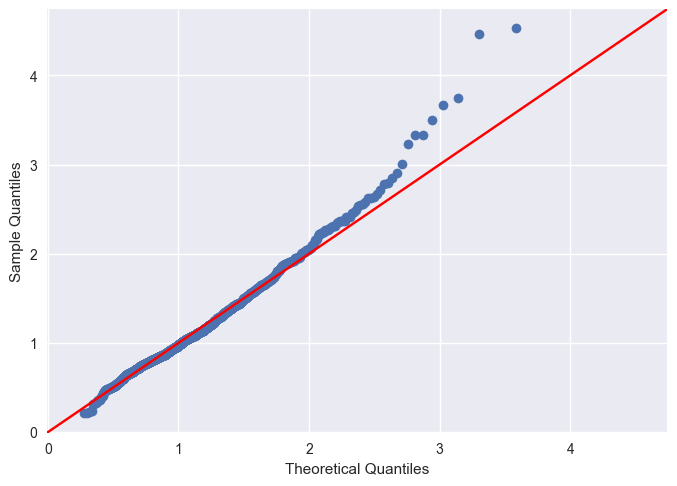

In [5]:
qqplot(train_raw['SalePrice'], dist = stats.distributions.lognorm, fit = True, line = '45')
plt.show()

Malgré la fonction logarithmique , certaines valeurs extrême émerge encore (maison chères) … ces données devront être analysées avec un éclairage métier afin de savoir si elles sont correctes. (par exemple une maison vendue en 99 en franc francais seraient super cher par rapport à une maison vendue en 2000 en euros)

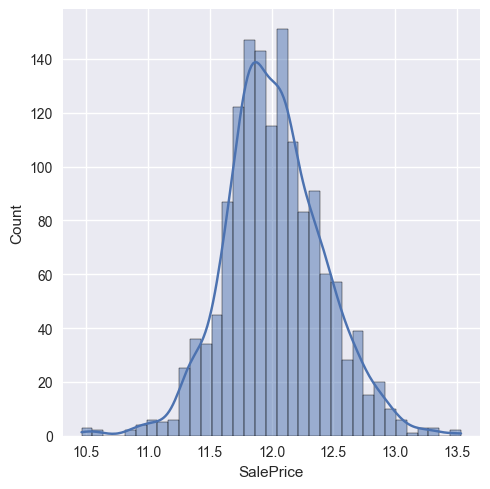

In [6]:
# new variable target which is the logarithm of the SalePrice
target = np.log1p(train_raw['SalePrice'])

# distribution plot
ax = sns.displot(data = target, kde=True)
plt.show()

## Traitement des données manquantes

On divise ensuite les variables en 3 catégories : ...

In [7]:
qualitative = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
              'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
              'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
              'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
              'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
              'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
              'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageFinish', 
              'GarageCars', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
              'SaleType', 'SaleCondition', 'MoSold']

quantitative = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1',  
               'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 
               'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 
               'PoolArea', 'MiscVal']

date = ['YearBuilt', 'YearRemodAdd', 'YrSold', 'GarageYrBlt']

In [8]:
data_raw = pd.concat([train_raw, validation_raw])

En ce qui concerne le traitement des données manquante , il faut être prudent et distinguer plusieurs cas, qui nécessiteront potentiellement des traitements différents.  Par exemple le nombre de mètres carrés d'une piscine: 0 veux dire qu'il n'y a pas de piscine ou alors qu'on ne sait pas sa taille? Dans ce cas on peut déduire que si il y a une piscine mais que son aire est à 0, on a pas l'info donc on peut y mettre la médiane par exemple.

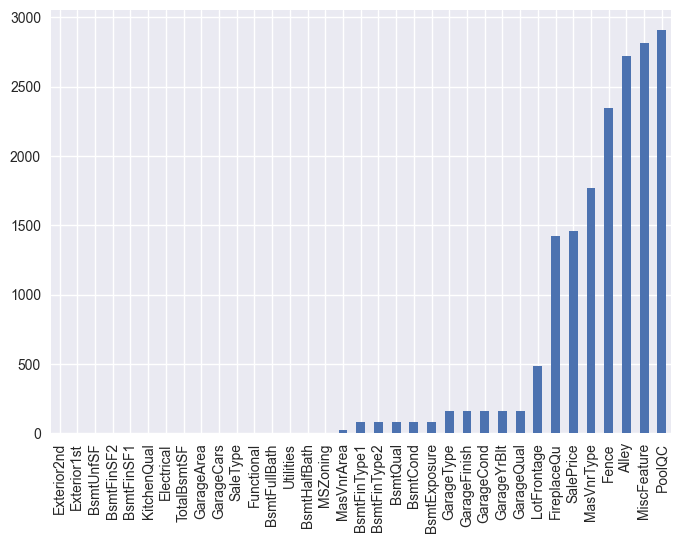

In [9]:
def plot_missing(data):

    missing = data.isnull().sum()
    missing = missing[missing > 0]
    
    if missing.empty:
        print('No missing values')
    else :
        missing.sort_values(inplace=True)
        missing.plot.bar()
    
        plt.show()

plot_missing(data_raw)

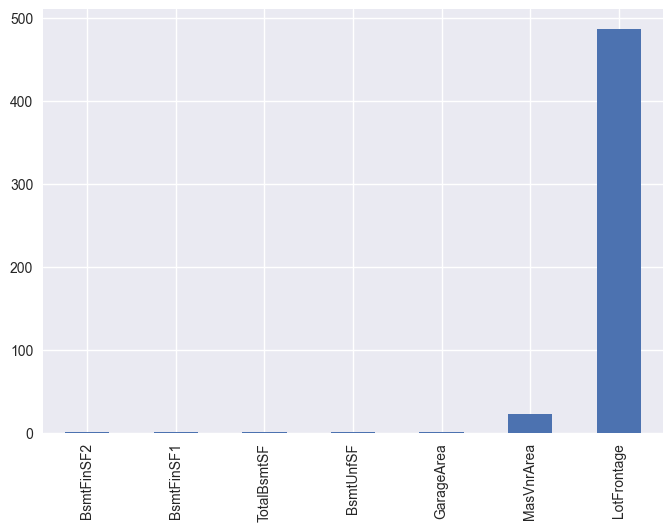

In [10]:
plot_missing(data_raw[quantitative])

In [11]:
# For quantitative variables, we will fill columns with 0
def fill_missing_with_constant(data, columns, constant):
    
    data_clean = data.copy()
    
    for c in columns :
        
        if data_clean[c].isnull().any():
            data_clean[c] = data_clean[c].fillna(constant)
    
    return data_clean

Voir les variables quantitatives manquantes :

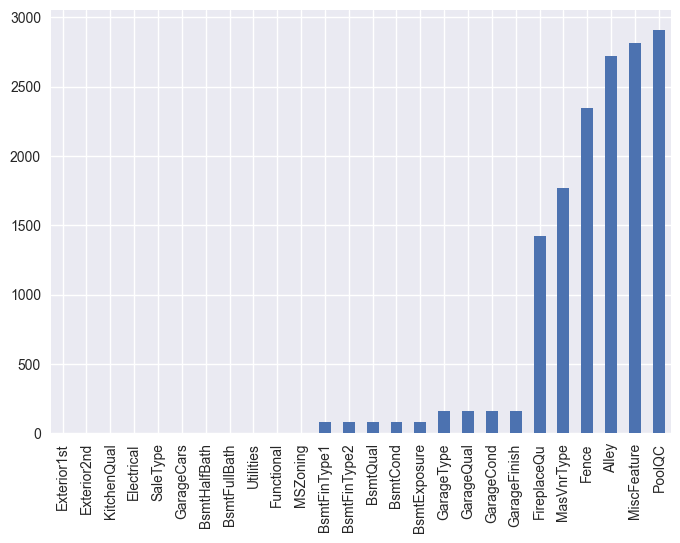

In [12]:
plot_missing(data_raw[qualitative])

Dates:
Données manquantes dans Garageyrbldt: on  met l'année de contruction de la maison (car en principe le garage est, au pire, aussi vieux que la maison mais pas plus)
 
afin de pouvoir exploiter des dates de façon mathématiques: il faut les transformer en nombre d'années.
1: année de vente - année de construction = nombre d'années qu'à la maison
2:  année de vente - année de rénovation =nombre d'années depuis la dernières rénovation
3: année de vente- année de construction garage = nombre d'années depuis la construction du garage

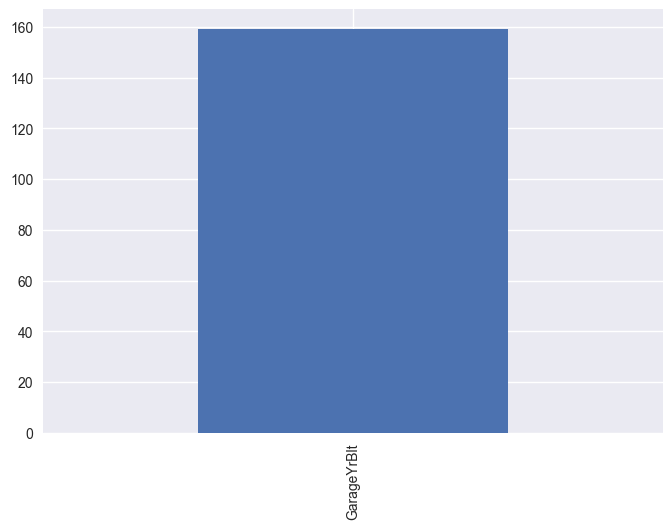

In [13]:
plot_missing(data_raw[date])

In [14]:
# For date variables, we will fill the missing values using the values from another column
def fill_missing_with_column(data, missing, column) :
    
    data_clean = data.copy()
    
    data_clean[missing] = np.where(data_clean[missing].isnull(), data_clean[column], data_clean[missing])
    
    return data_clean

## Transformation des dates

Transformer des dates absolues en durées relatives à la date de vente (YrSold) :

- Années depuis construction
- Années depuis rénovation
- Années depuis construction du garage

In [15]:
def compute_differences_to_year_sold(data) :
    
    data_clean = data.copy()
    
    data_clean['YearBuilt'] = data_clean['YrSold'] - data_clean['YearBuilt']
    data_clean['YearRemodAdd'] = data_clean['YrSold'] - data_clean['YearRemodAdd']
    data_clean['GarageYrBlt'] = data_clean['YrSold'] - data_clean['GarageYrBlt']
    
    return data_clean

## Nettoyage
On centralise toutes les étapes de nettoyage des données dans une seule fonction appelée clean(), afin de l’exécuter d’un seul coup sur le jeu de données brut (data_raw), qui contient à la fois le train et le test.

In [16]:
def clean(data) :
    
    data_clean = data.copy()
    
    # imputing missing variables
    data_clean = fill_missing_with_constant(data_clean, columns = quantitative, constant = 0)
    data_clean = fill_missing_with_constant(data_clean, columns = qualitative, constant = 'NA')
    data_clean = fill_missing_with_column(data_clean, missing = ['GarageYrBlt'], column = ['YearBuilt'])

    # transform date columns
    data_clean = compute_differences_to_year_sold(data_clean)
    
    return data_clean

On lance le process de nettoyage

In [17]:
data_clean = clean(data_raw)

data_clean.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NA,Reg,Lvl,AllPub,Inside,...,0,NA,NA,NA,0,2,2008,WD,Normal,208500.0
2,20,RL,80.0,9600,Pave,NA,Reg,Lvl,AllPub,FR2,...,0,NA,NA,NA,0,5,2007,WD,Normal,181500.0
3,60,RL,68.0,11250,Pave,NA,IR1,Lvl,AllPub,Inside,...,0,NA,NA,NA,0,9,2008,WD,Normal,223500.0
4,70,RL,60.0,9550,Pave,NA,IR1,Lvl,AllPub,Corner,...,0,NA,NA,NA,0,2,2006,WD,Abnorml,140000.0
5,60,RL,84.0,14260,Pave,NA,IR1,Lvl,AllPub,FR2,...,0,NA,NA,NA,0,12,2008,WD,Normal,250000.0


# Modèle Baseline

**Section à supprimer ?**

Un modèle baseline est une première version simple d'un modèle de machine learning, utilisé comme point de comparaison pour évaluer les performances des modèles qui seront développés par la suite. Il permet d'établir un point de départ et ainsi identifier les apports des modèles plus complexes. Pour notre premier modèle, nous allons réaliser une régression linéaire simple.

JUSTIFIER

## Sélection des paramètres

Sélection basée sur la corrélation avec la méthode de Pearson. Pour ce faire, aucune transformation n’a été appliquée aux variables numériques, les variables catégorielles ont été encodées par la moyenne de la cible, et les variables de type date ont été transformées en nombre d’années depuis la vente.

Nous avons évité les variables trop liées entre elles grâce à la heatmap

[Introduire HeatMap]



Choix limité à 5 variables

Attention, d'un point de vue **interprétation**: les années ont une corrélation négative (plus c'est ancien, moins cela a de valeur)



**Variables**:
- OverallQual (l’évaluation globale de la qualité), Corrélation avec log(SalePrice) : +0.83 (la plus élevée)
- GrLivArea (surface habitable hors sous-sol, critère principal pour la taille du bien), Corrélation avec log(SalePrice) : +0.70
- TotalBsmtSF (surface totale du sous-sol, complète très bien GrLivArea en couvrant l’espace habitable invisible depuis les plans officiels,moins redondante que 1stFlrSF ou BsmtFinSF1), Corrélation avec log(SalePrice) : +0.62
- YearBuilt (l’ancienneté générale de la maison),capture toute l’infrastructure du bien. Des maisons anciennes dans des quartiers chers peuvent valoir plus qu’une maison récente dans un quartier médiocre. Corrélation négative avec log(SalePrice) : -0.59
- Neighborhood (quartier), variable la plus discriminante parmi toutes les catégorielles. Après son encodage en moyenne, corrélation de  +0.75 avec log(SalePrice)

**Utilité de chaque variable**:
- OverallQual: Qualité globale
- GrLivArea: Taille / Surface
- TotalBsmtSF: Surface complémentaire
- Neighborhood: Emplacement
- YearBuilt: Axe temporel

## Régression linéaire

Dans cette section, nous allons fit / adapter le modèle sur les données d'entraînement. Avant cela, nous devons séparer les données numériques, de celles catégoriques, afin d'apporter un traitement différent via des transformateurs. Ensuite un pipeline est créé pour regrouper les étapes à réaliser. Finalement, une cross-validation est réalisée afin de connaître le score moyen.

In [18]:
# Données nettoyées
data_clean = clean(data_raw)

# Variables de base
base = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'Neighborhood', 'YearBuilt']
x = data_clean[data_clean.index.isin(train_raw.index)][base].copy()
y = target.copy()

X_encoded = pd.get_dummies(x, columns=['Neighborhood'], drop_first=True)
X_array = sm.add_constant(X_encoded).astype(float)

# Création et entraînement du modèle de régression linéaire
model = sm.OLS(y, X_array)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.836
Model:                            OLS   Adj. R-squared:                  0.832
Method:                 Least Squares   F-statistic:                     259.9
Date:                Sun, 01 Jun 2025   Prob (F-statistic):               0.00
Time:                        16:30:24   Log-Likelihood:                 586.90
No. Observations:                1460   AIC:                            -1116.
Df Residuals:                    1431   BIC:                            -962.5
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   10.9769 

### Assomptions du modèle

If we want to use a linear regression, we need to check certain assumptions, namely :

- Linearity of the link between the independant variables and the depedant variable
- Residuals are normally distributed around 0
- Homoscedasticity
- Residuals are free of structure
- Residuals are free of outliers

The following is a code I've found https://robert-alvarez.github.io/2018-06-04-diagnostic_plots/ which does this very well.

### VERFI ASSOMPTIONS

## Prédiction et soumission sur Kaggle

Une fois le modèle fit / adapté, nous pouvons prédire les valeurs cibles manquantes dans notre jeu de données de validation. Attention à ne pas le faire sur le jeu de données d'entraînement ! Cela ne sert à rien, le résultat sera biaisé car nous avons entraîné le modèle sur ces mêmes données.

Ensuite, nous allons exporter les prédictions dans un fichier csv, qui sera soumis à Kaggle. Ce modèle Baseline obtient un score de 0.16482.

-> A vérifier mais je dirais que pour chaque résultat il faut comparer en se basant sur RMSLE. Je l'ai fait sur RMSE mais peut-être faux, le RMSLE c'est pour les données logarithmiques ?$

Réponse GPT : "RMSLE est utile si tu prédis directement les prix bruts. Mais ici, tu prédis déjà le log → donc utilise RMSE directement."

# Pipeline de prétraitement

In [19]:
# ----------------------
# 1. Charger les données brutes
# ----------------------

train_raw = pd.read_csv('Data/train.csv', index_col='Id')      # train.csv avec target SalePrice
test_raw = pd.read_csv('Data/test.csv', index_col='Id')        # test.csv sans SalePrice
data_raw = pd.concat([train_raw.drop(columns='SalePrice').copy(), test_raw.copy()])  # concat pour traitement centralisé

# ----------------------
# 2. Définir les colonnes utiles pour la pipeline
# ----------------------

numerical_cols = quantitative
categorical_cols = qualitative
date_cols = date 

# ----------------------
# 3. Fonction de transformation des dates en durées
# ----------------------

def compute_relative_dates(df):
    df = df.copy()
    df['YearsSinceBuilt'] = df['YrSold'] - df['YearBuilt']
    df['YearsSinceRemod'] = df['YrSold'] - df['YearRemodAdd']
    df['YearsSinceGarage'] = df['YrSold'] - df['GarageYrBlt'].fillna(df['YearBuilt'])
    return df[['YearsSinceBuilt', 'YearsSinceRemod', 'YearsSinceGarage']]


# Transformer scikit-learn compatible avec la nouvelle fonction date
date_transformer = Pipeline(steps=[
    ('relativedates', FunctionTransformer(compute_relative_dates, validate=False))
])

# ----------------------
# 4. Pipeline pour les colonnes numériques
# ----------------------

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),     # remplace les NaN par la moyenne
    ('scaler', StandardScaler())                     # normalise (utile pour modèles linéaires, SVM…)
])

# ----------------------
# 5. Pipeline pour les colonnes catégorielles
# ----------------------

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),  # ajoute une vraie catégorie "Missing"
    ('encoder', OneHotEncoder(handle_unknown='ignore'))                     # transforme en colonnes binaires, ignore les inconnues au test
])

# ----------------------
# 6. Assemblage global via ColumnTransformer
# ----------------------

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numerical_cols),       # traitement des numériques
    ('cat', categorical_transformer, categorical_cols), # traitement des catégorielles
    ('dates', date_transformer, date_cols)              # traitement des dates
], remainder='drop')  

# ----------------------
# 7. Préparation des données
# ----------------------
X_train = data_raw.loc[train_raw.index]
X_test = data_raw.loc[test_raw.index]
y_train = target.copy()

# ----------------------
# 8. Exemple d’utilisation (sans modèle)
# ----------------------

preprocessing_pipeline = Pipeline([
    ('preprocessor', preprocessor)
])

preprocessing_pipeline


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['LotFrontage', 'LotArea',
                                                   'OverallQual', 'OverallCond',
                                                   'MasVnrArea', 'BsmtFinSF1',
                                                   'BsmtFinSF2', 'BsmtUnfSF',
                                                   'TotalBsmtSF', '1stFlrSF',
                                                   '2ndFlrSF', 'LowQualFinSF',
                                                   'GrLivArea', 'GarageArea',
                                                   'WoodDeckSF', 'OpenPorchSF...
                                                   'Exterior1st', 'Exterior2nd',
                                                   'MasVnrType', 'ExterQual',
                                                   'ExterCond', 'Foundation',
                                                   'BsmtQual', 'BsmtCond',
                                                   'BsmtExposure',
                                                   'BsmtFinType1',
                                                   'BsmtFinType2', 'Heating',
                                                   'HeatingQC', 'CentralAir', ...]),
                                                 ('dates',
                                                  Pipeline(steps=[('relativedates',
                                                                   FunctionTransformer(func=<function compute_relative_dates at 0x00000215F1E1ACA0>))]),
                                                  ['YearBuilt', 'YearRemodAdd',
                                                   'YrSold',
                                                   'GarageYrBlt'])]))])

# Modèle 1 - Random Forest

In [20]:
# ----------------------
# Méthode pour optimiser le modèle RandomForest
# ----------------------
def random_forest_objective(trial, preprocessing_pipeline, X, y, cv, scoring):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 5, 40),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    }
    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', model)
    ])
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    return -scores.mean()

Pour ce modèle `Random Forest Regressor`, différents tests ont été réalisés afin de sélectioner les meilleures plages d'hyperparamètres. Voici une justification pour chaque paramètre :
 - **n_estimators** : plus le nombre d'arbres est élevé, plus le modèle est stable. Cependant, ils ont été limités à 1000 afin d'éviter un temps d'entrainement trop conséquent.
 - **max_depth** : Une bonne profondeur est indispensable pour éviter l'overfitting et l'underfitting. Une taille trop petite est trop restrictive et au dela de 40 est peu utile pour un data set moyen comme celui-ci (environ 1400 lignes)
 - **min_samples_split** : En augmentant cette valeur, il est possible d'éviter l'overfitting. L'objectif est donc de laisser une certaine liberté au modèle, afin qu'il puisse avoir des splits profonds (2) ou plus restreints (20).
 - **min_samples_leaf** : Pour cet hyperparamètre, une certaine liberté est donnée également. Le fait d'avoir une valeur petite (1) peut rendre le modèle sensible au bruit, il faut donc avoir une valeur maximale (10) cohérente pour forcer des règles plus générales.
 - **max_features** : Cette valeur permet de réduire le nombre de features candidates pour chaque noeud, le but est donc de donner trois façons de faire plus ou moins restrictives pour permettre de tester des cas différents.

# Modèle 2 - Régression Lasso

In [21]:
# ----------------------
# Méthode pour optimiser le modèle Lasso
# ----------------------
def lasso_objective(trial, preprocessing_pipeline, X, y, cv, scoring):
    alpha = trial.suggest_float('alpha', 1e-4, 10.0, log=True)
    model = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', model)
    ])
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    return -scores.mean()

Pour modèle, le seul hyperparamètres intéressant est l'alpha. Ce dernier contrôle la force de la régularisation L1 appliquée. Un alpha faible donne un modèle très flexible, qui risque de surajuster. Alors qu'un grand alpha offre une régularisation forte et donc un modèle très rigide (car de nombreux coefficients seront faibles). Comme nous avons un data set moyen avec beaucoup de features (365), un risque de surajustement existe. Ici la borne supérieure (10) nous permet de ne pas avoir un modèle trop rigide et sous-ajusté. 

Nous sommes conscients que certains modèles (comme Lasso ou Ridge) peuvent présenter un `second sweet spot` pour des valeurs extrêmes d’hyperparamètres, mais cette hypothèse ne sera pas explorée dans le cadre de ce projet.

# Modèle 3 - Decision Tree

In [22]:
# ----------------------
# Méthode pour optimiser le modèle DecisionTree
# ----------------------
def decision_tree_objective(trial, preprocessing_pipeline, X, y, cv, scoring):
    
    params = {
        'max_depth': trial.suggest_int('max_depth', 10, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 15),
        'max_features': trial.suggest_categorical('max_features', [None,'sqrt'] )
    }

    model = DecisionTreeRegressor(**params, random_state=42)

    pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', model)
    ])

    scores = cross_val_score(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)

    return -scores.mean()

# Modèle 4 - XGBoost

In [23]:
# ----------------------
# Méthode pour optimiser le modèle XGBoost
# ----------------------
def xgboost_objective(trial, preprocessing_pipeline, X, y, cv, scoring):
    params = {
        'eta': trial.suggest_float('eta', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 500, 1200),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 0.3),
        'alpha': trial.suggest_float('alpha', 1e-6, 100, log=True),
        'lambda': trial.suggest_float('lambda', 1e-6, 100, log=True)
    }

    model = XGBRegressor(**params, objective='reg:squarederror', random_state=42, n_jobs=-1)

    pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', model)
    ])

    scores = cross_val_score(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)

    return -scores.mean()

# Evaluation des modèles

In [24]:
def evaluate_and_optimize_models(model_configs, X, y, preprocessing_pipeline, cv=5, n_trials=30, scoring='neg_root_mean_squared_error'):
    """
    Optimise les modèles avec Optuna puis évalue leur performance via validation croisée.

    Paramètres:
    - model_configs: dict[str, callable], nom du modèle -> fonction objective(trial, pipeline, X, y)
    - X, y: données d'entrée brutes (non transformées)
    - preprocessing_pipeline: pipeline de prétraitement à injecter dans chaque modèle
    - cv: nombre de folds pour la cross-validation
    - n_trials: nombre d’essais pour Optuna
    - scoring: métrique (RMSE négatif par défaut)

    Retourne : dict avec les résultats RMSE moyens + std
    """

    results = {}

    for name, objective_func in model_configs.items():
        print(f"\nOptimisation pour : {name}")

        def wrapped_objective(trial):
            return objective_func(trial, preprocessing_pipeline, X, y, cv, scoring)

        study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42), study_name=name)
        study.optimize(wrapped_objective, n_trials=n_trials, show_progress_bar=True)

        best_score = study.best_value
        best_params = study.best_params
        print(f"✅ {name} | RMSE = {best_score:.4f} | Paramètres: {best_params}")
        print("------------------------------------")

        results[name] = (best_score, best_params, study)
    
    # Affichage graphique
    names = list(results.keys())
    means = [results[name][0] for name in names]

    plt.figure(figsize=(10, 5))
    plt.bar(names, means)
    plt.ylabel("Meilleur RMSE (CV)")
    plt.title("Comparaison des modèles optimisés")
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

    return results

[I 2025-06-01 16:30:25,097] A new study created in memory with name: Random Forest



Optimisation pour : Random Forest


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-06-01 16:30:30,052] Trial 0 finished with value: 0.16314922591757933 and parameters: {'n_estimators': 437, 'max_depth': 39, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.16314922591757933.
[I 2025-06-01 16:30:35,698] Trial 1 finished with value: 0.15347119864692182 and parameters: {'n_estimators': 880, 'max_depth': 26, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.15347119864692182.
[I 2025-06-01 16:30:44,872] Trial 2 finished with value: 0.14695174134339903 and parameters: {'n_estimators': 263, 'max_depth': 11, 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_features': None}. Best is trial 2 with value: 0.14695174134339903.
[I 2025-06-01 16:30:45,906] Trial 3 finished with value: 0.15986839509130027 and parameters: {'n_estimators': 225, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.1469517

[I 2025-06-01 18:58:29,354] A new study created in memory with name: Lasso


...

[I 2025-06-01 18:59:03,353] Trial 0 finished with value: 0.18753359703680367 and parameters: {'max_depth': 17, 'min_samples_split': 20, 'min_samples_leaf': 14, 'max_features': None}. Best is trial 0 with value: 0.18753359703680367.
[I 2025-06-01 18:59:03,470] Trial 1 finished with value: 0.22455167927387037 and parameters: {'max_depth': 13, 'min_samples_split': 3, 'min_samples_leaf': 15, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.18753359703680367.
[I 2025-06-01 18:59:03,629] Trial 2 finished with value: 0.18757090449527075 and parameters: {'max_depth': 10, 'min_samples_split': 20, 'min_samples_leaf': 14, 'max_features': None}. Best is trial 0 with value: 0.18753359703680367.
[I 2025-06-01 18:59:03,780] Trial 3 finished with value: 0.18548949891350536 and parameters: {'max_depth': 13, 'min_samples_split': 7, 'min_samples_leaf': 13, 'max_features': None}. Best is trial 3 with value: 0.18548949891350536.
[I 2025-06-01 18:59:03,899] Trial 4 finished with value: 0.2259079597958

[I 2025-06-01 18:59:20,879] A new study created in memory with name: XGBoost


[I 2025-06-01 18:59:20,877] Trial 99 finished with value: 0.18538111962233986 and parameters: {'max_depth': 15, 'min_samples_split': 3, 'min_samples_leaf': 12, 'max_features': None}. Best is trial 12 with value: 0.18538111962233986.
✅ Decision Tree | RMSE = 0.1854 | Paramètres: {'max_depth': 29, 'min_samples_split': 2, 'min_samples_leaf': 12, 'max_features': None}
------------------------------------

Optimisation pour : XGBoost


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-06-01 18:59:21,554] Trial 0 finished with value: 0.1576764326604003 and parameters: {'eta': 0.11861663446573512, 'n_estimators': 1166, 'max_depth': 16, 'min_child_weight': 8, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'gamma': 0.017425083650459836, 'alpha': 8.499808989183016, 'lambda': 0.06440507553993717}. Best is trial 0 with value: 0.1576764326604003.
[I 2025-06-01 18:59:22,006] Trial 1 finished with value: 0.13562294942241618 and parameters: {'eta': 0.21534104756085318, 'n_estimators': 514, 'max_depth': 20, 'min_child_weight': 9, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503, 'gamma': 0.055021352956030146, 'alpha': 0.000271605114465485, 'lambda': 0.01577798188336503}. Best is trial 1 with value: 0.13562294942241618.
[I 2025-06-01 18:59:22,419] Trial 2 finished with value: 0.1405693361360239 and parameters: {'eta': 0.13526405540621358, 'n_estimators': 704, 'max_depth': 14, 'min_child_weight': 5, 'subsample': 0.646072324

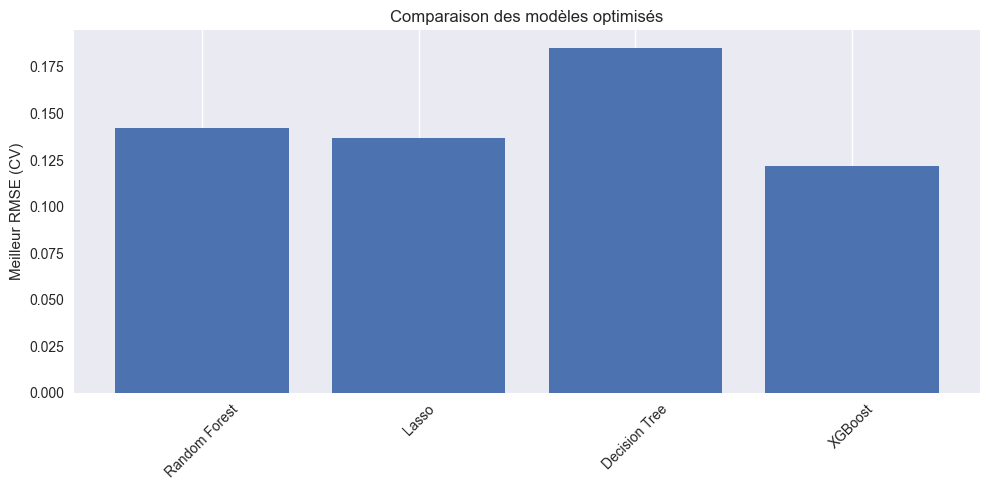

In [25]:
# ----------------------
# Exécution de l'optimisation et de l'évaluation des modèles
# ----------------------
model_configs = {
    'Random Forest': random_forest_objective,
    'Lasso': lasso_objective,
    'Decision Tree': decision_tree_objective,
    'XGBoost': xgboost_objective
}

results = evaluate_and_optimize_models(model_configs, X_train, y_train, preprocessing_pipeline, n_trials=100)

random_forest_best_params = results['Random Forest'][1]
lasso_best_params = results['Lasso'][1]
decision_tree_best_params = results['Decision Tree'][1]
xgboost_best_params = results['XGBoost'][1]

random_forest_study = results['Random Forest'][2]
lasso_study = results['Lasso'][2]
decision_tree_study = results['Decision Tree'][2]
xgboost_study = results['XGBoost'][2]

In [26]:
# ----------------------
# Méthode d'évaluation finale avec une validation croisée de 10 "folds" 
# ----------------------
def evaluate_final_cv(model_name, model_class, best_params, preprocessing_pipeline, X, y, cv=10, scoring='neg_root_mean_squared_error'):
    model = model_class(**best_params, random_state=42)

    pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', model)
    ])

    scores = cross_val_score(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    mean_rmse = -scores.mean()
    std_rmse = -scores.std()

    print(f"\nÉvaluation finale (cv 10) pour {model_name} :")
    print(f"✅ RMSE moyen : {mean_rmse:.5f}")
    print(f"📏 Écart-type : {std_rmse:.5f}")
    print("------------------------------------")
    
    return mean_rmse, std_rmse

evaluate_final_cv("Random Forest", RandomForestRegressor, random_forest_best_params, preprocessing_pipeline, X_train, y_train)
evaluate_final_cv("Lasso", Lasso, lasso_best_params, preprocessing_pipeline, X_train, y_train)
evaluate_final_cv("Decision Tree", DecisionTreeRegressor, decision_tree_best_params, preprocessing_pipeline, X_train, y_train)
evaluate_final_cv("XGBoost", XGBRegressor, xgboost_best_params, preprocessing_pipeline, X_train, y_train)


Évaluation finale (cv 10) pour Random Forest :
✅ RMSE moyen : 0.13989
📏 Écart-type : -0.01831
------------------------------------

Évaluation finale (cv 10) pour Lasso :
✅ RMSE moyen : 0.13338
📏 Écart-type : -0.04345
------------------------------------

Évaluation finale (cv 10) pour Decision Tree :
✅ RMSE moyen : 0.18224
📏 Écart-type : -0.01547
------------------------------------

Évaluation finale (cv 10) pour XGBoost :
✅ RMSE moyen : 0.12250
📏 Écart-type : -0.01744
------------------------------------


(np.float64(0.12249527804171971), np.float64(-0.017435678172299855))

A noter que les plages des hyperparamètres n'ont pas été sélectionnées au hasard. Elles ont été choisies à la suite d'analyse de graphiques Optuna `plot_slice`. Des itérations ont été réalisées mais pour éviter de surcharger ce document, nous n'avons inséré que le dernier graphique de chaque modèle (voir ci-dessous).

In [27]:
print("\nVisualisation des études Optuna pour Random Forest :")
plot_slice(random_forest_study).show()

print("\nVisualisation des études Optuna pour Lasso :")
plot_slice(lasso_study).show()

print("\nVisualisation des études Optuna pour Decision Tree :")
plot_slice(decision_tree_study).show()

print("\nVisualisation des études Optuna pour XGBoost :")
plot_slice(xgboost_study).show()


Visualisation des études Optuna pour Random Forest :



Visualisation des études Optuna pour Lasso :



Visualisation des études Optuna pour Decision Tree :



Visualisation des études Optuna pour XGBoost :


Justification pour le Decision Tree :
 - Plusieurs essais des plages, ce qui a été fait après les résultats de slice plot:
 - Max_depth initialement large, resserrée entre 10–30
 - Max_features, log2 était sous-performant et a été retiré
 - Pour min_samples_leaf, les meilleures performances sont entre 10 et 15

Justification pour XGBoost : 
 - On a augmenté le nombre minimal d’arbres (n_estimators) car le modèle montrait de meilleures performances
 - On a limité la profondeur (max_depth) pour éviter la surcomplexité.
 - On a retiré les petites valeurs de min_child_weight et les grands gamma, qui tendaient à dégrader la performance 

In [41]:
model = XGBRegressor(**xgboost_best_params, objective='reg:squarederror', random_state=42, n_jobs=-1)

model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('xgboost', model)
    ])

model_pipeline.fit(X_train, y)

y_pred = model_pipeline.predict(X_test)

kaggle_submission = pd.DataFrame()
kaggle_submission['Id'] = X_test.index
kaggle_submission['SalePrice'] = np.expm1(y_pred)
kaggle_submission.to_csv('Data/xgboost.csv', index=False)

## Modèle Stacking Regressor

In [28]:
def stacking_objective(trial, preprocessing_pipeline, X, y, cv, scoring):
    lasso_pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', Lasso(lasso_best_params['alpha'], max_iter=10000, random_state=42))
    ])

    random_forest_pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', RandomForestRegressor(
            n_estimators=random_forest_best_params['n_estimators'],
            max_depth=random_forest_best_params['max_depth'],
            min_samples_split=random_forest_best_params['min_samples_split'],
            min_samples_leaf=random_forest_best_params['min_samples_leaf'],
            max_features= random_forest_best_params['max_features'],
            random_state=42,
            n_jobs=-1
        ))

    ])

    decision_tree_pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', DecisionTreeRegressor(
            max_depth=decision_tree_best_params['max_depth'],
            min_samples_split=decision_tree_best_params['min_samples_split'],
            min_samples_leaf=decision_tree_best_params['min_samples_leaf'],
            max_features=decision_tree_best_params['max_features'],
            random_state=42
        ))
    ])

    xgboost_pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', XGBRegressor(
            eta=xgboost_best_params['eta'],
            n_estimators=xgboost_best_params['n_estimators'],
            max_depth=xgboost_best_params['max_depth'],
            min_child_weight=xgboost_best_params['min_child_weight'],
            subsample=xgboost_best_params['subsample'],
            colsample_bytree=xgboost_best_params['colsample_bytree'],
            gamma=xgboost_best_params['gamma'],
            alpha=xgboost_best_params['alpha'],
            lambda_=xgboost_best_params['lambda'],
            objective='reg:squarederror',
            random_state=42,
            n_jobs=-1
        ))
    ])

    # Modifier les paramètres du Ridge ? (Alpha)
    final_estimator = Ridge(alpha=trial.suggest_float('ridge_alpha', 0.01, 10.0, log=True))

    stacking = StackingRegressor(
        estimators=[
            ('lasso', lasso_pipeline),
            ('random_forest', random_forest_pipeline),
            ('decision_tree', decision_tree_pipeline),
            ('xgboost', xgboost_pipeline)
        ],
        final_estimator=final_estimator,
        cv=cv,
        n_jobs=-1
    )

    scores = cross_val_score(stacking, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    return -scores.mean()

[I 2025-06-01 21:11:37,763] A new study created in memory with name: Stacking



Optimisation pour : Stacking


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-06-01 21:17:14,752] Trial 0 finished with value: 0.12429761707339182 and parameters: {'ridge_alpha': 0.13292918943162169}. Best is trial 0 with value: 0.12429761707339182.
[I 2025-06-01 21:22:30,195] Trial 1 finished with value: 0.12454188082955467 and parameters: {'ridge_alpha': 7.114476009343421}. Best is trial 0 with value: 0.12429761707339182.
[I 2025-06-01 21:27:45,345] Trial 2 finished with value: 0.12404684522724056 and parameters: {'ridge_alpha': 1.5702970884055387}. Best is trial 2 with value: 0.12404684522724056.
[I 2025-06-01 21:33:05,091] Trial 3 finished with value: 0.12410229012900191 and parameters: {'ridge_alpha': 0.6251373574521749}. Best is trial 2 with value: 0.12404684522724056.
[I 2025-06-01 21:38:30,847] Trial 4 finished with value: 0.1243806649191842 and parameters: {'ridge_alpha': 0.02938027938703535}. Best is trial 2 with value: 0.12404684522724056.
[I 2025-06-01 21:44:04,464] Trial 5 finished with value: 0.12438066940657558 and parameters: {'ridge_alph

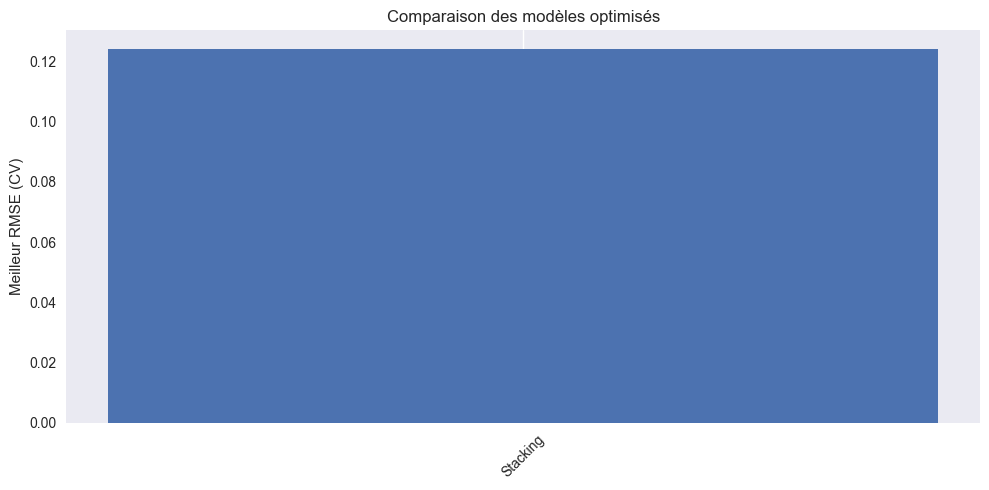

In [33]:
model_configs = {
    'Stacking': stacking_objective
}
results = evaluate_and_optimize_models(model_configs, X_train, y_train, preprocessing_pipeline, n_trials=20)

In [40]:
stacking_best_params = results['Stacking'][1]

model = Ridge(alpha=stacking_best_params['ridge_alpha'])

model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('stacking', model)
    ])

model_pipeline.fit(X_train, y)

y_pred = model_pipeline.predict(X_test)

kaggle_submission = pd.DataFrame()
kaggle_submission['Id'] = X_test.index
kaggle_submission['SalePrice'] = np.expm1(y_pred)
kaggle_submission.to_csv('Data/stacking.csv', index=False)

# Conclusion

Ophélie

## Éthique